# Unsupervised NN

### Model Character
input:
- distribution of d_k (sum = 1)
- |H_k|

output:
- list of b_k
- list of f_dt_k
- list of beta_k

In [45]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
import numpy as np
import torch


if torch.backends.mps.is_available():
    device = 'mps'
    print("Success: Using Apple Silicon GPU acceleration.")
elif torch.cuda.is_available():
    device = 'cuda'
    print("Success: Using Cuda GPU acceleration.")
else:
    device = 'cpu'
    print("Using CPU.")

Success: Using Cuda GPU acceleration.


## Training

In [47]:
from TrainingUtil import set_seed

set_seed()

In [48]:
from DataUtil import generate_data_loader
import Constants

K = 8
B_total = Constants.total_bandwidth
C_DT_total = Constants.total_compute_speed

train_loader, test_loader = generate_data_loader(
    int(1e4), 
    K, K * 4e3, 
    comp_speed_range=[Constants.sensor_compression_speed/2, Constants.sensor_compression_speed*2], 
    tr_power_range=[Constants.transmit_power/2, Constants.transmit_power*2],
    beta_max=Constants.beta_max
    )

In [49]:
from TrainingUtil import unsupervised_loss, train
from torch.optim import Adam, lr_scheduler
from EarlyStopping import EarlyStopping
from NNSolver import Net
import Constants as c

model = Net(K, B_total, C_DT_total, c.beta_max)

optimizer = Adam(model.parameters(), lr=0.01)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
early_stopper = EarlyStopping(patience=4, min_delta=0.1)
loss_fn = unsupervised_loss

train(model, train_loader, test_loader, optimizer, scheduler, early_stopper, loss_fn, device, n_epoch=100)

start training
epoch: 01, avg loss: 637.6312052408854
epoch: 02, avg loss: 637.7500406901041
epoch: 03, avg loss: 637.6434936523438
epoch: 04, avg loss: 637.6359659830729
epoch: 05, avg loss: 637.6822102864584
best epoch: 01, best avg loss: 637.631205


In [50]:
# state_dict = torch.load('model/checkpoint.pth', map_location=device, weights_only=True)
# model.to(device)
# model.load_state_dict(state_dict)

## Validation

In [51]:
# from NNSolver import Net
# model = Net(K, B_total, C_DT_total, beta_max).to(device)
# model.load_state_dict(torch.load('model/checkpoint.pth'))

In [52]:
import TrainingUtil as tu
import DataUtil as du
import AnalyzeUtil as au
import ProcessTime as process

uniform = torch.ones(K)
benchmark = torch.tensor([0.25, 0.75, 1.25, 1.75])

H = au.to_normal(-40)

H_k = torch.ones(K) * H
test_d = uniform * 4e3
test_beta = torch.ones(K) * 1.5
test_comp_speed = uniform * Constants.sensor_compression_speed
test_tr_power = uniform * Constants.transmit_power
# test_comp_speed = torch.tensor([1, 1, 1, 1]) * 200e3
X_test = torch.cat((test_d, H_k, test_beta, test_comp_speed, test_tr_power)).reshape(1, -1).to(device)

NN

|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            1 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            2 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            3 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            4 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            5 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            6 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            7 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |

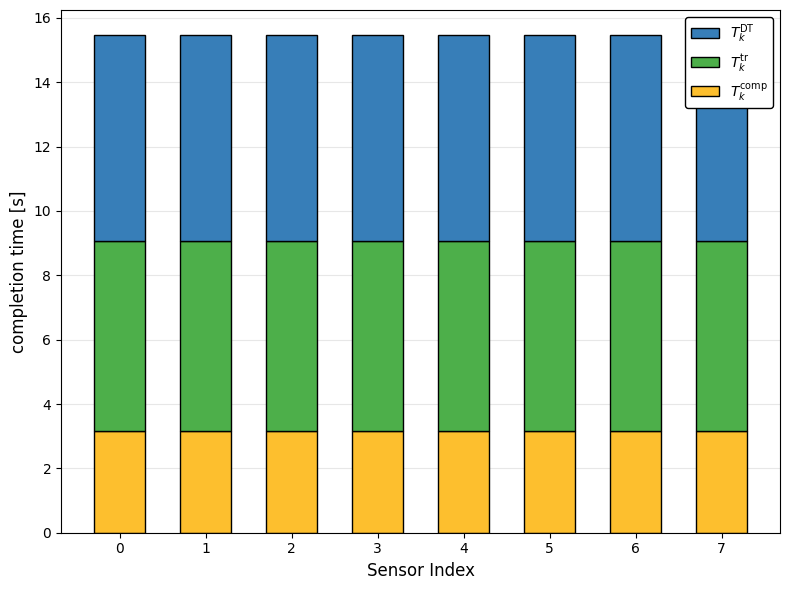

In [53]:
b, f = model(X_test)

b = b.to('cpu')
f = f.to('cpu')
au.plot_result(X_test.to('cpu'), b, f)
au.print_avg(X_test.to('cpu'), b, f)


CVX

|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            1 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            2 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            3 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            4 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            5 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            6 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |
|            7 | 4.00e+03 |  -40.00 | 1.250e+04 | 6.250e+06 |   1.50 |     2.00e+05 |   3.16e-02 |         15.47 |         3.15 |       5.92 |       6.40 |

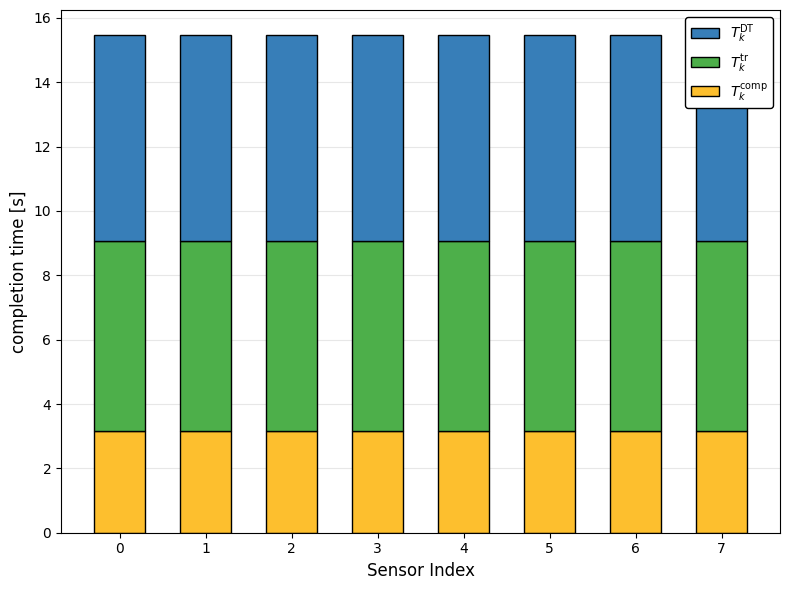

In [54]:
from CVXSolver import CVXSolver

cvx_solver = CVXSolver(
    K=K,
    B_total=Constants.total_bandwidth,
    C_DT_total=Constants.total_compute_speed,
    beta_max=Constants.beta_max,
)

b_cvx, f_cvx = cvx_solver.predict(X_test, verbose=False)

b_cvx = torch.tensor(b_cvx)
f_cvx = torch.tensor(f_cvx)

au.plot_result(X_test.to('cpu'), b_cvx, f_cvx)
au.print_avg(X_test.to('cpu'), b_cvx, f_cvx)

## Algorithm

In [62]:
from Problem import Problem

uniform = np.ones((1,K))
benchmark = np.array([0.25, 0.75, 1.25, 1.75])

rep = 100

D = (uniform * 4e3 ).reshape(1, -1)
D = np.repeat(D, rep, axis=0)

H = du.generate_channel_gains(rep, K).numpy()

comp_speed = (uniform * Constants.sensor_compression_speed).reshape(1, -1).repeat(rep, axis=0)

tr_power = (uniform * Constants.transmit_power).reshape(1, -1).repeat(rep, axis=0)

algo = Problem(D, H, comp_speed, tr_power)

NN

|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 4.00e+03 |  -40.70 | 1.248e+04 | 5.588e+06 |   1.34 |     2.00e+05 |   3.16e-02 |         40.29 |         1.87 |      12.80 |      25.62 |
|            1 | 4.00e+03 |  -40.78 | 1.254e+04 | 7.567e+06 |   1.35 |     2.00e+05 |   3.16e-02 |         40.29 |         2.37 |      16.67 |      21.24 |
|            2 | 4.00e+03 |  -40.62 | 1.245e+04 | 5.637e+06 |   1.33 |     2.00e+05 |   3.16e-02 |         40.29 |         1.71 |      11.59 |      26.99 |
|            3 | 4.00e+03 |  -40.64 | 1.245e+04 | 5.193e+06 |   1.33 |     2.00e+05 |   3.16e-02 |         40.29 |         1.65 |      11.23 |      27.41 |
|            4 | 4.00e+03 |  -40.61 | 1.246e+04 | 6.944e+06 |   1.33 |     2.00e+05 |   3.16e-02 |         40.29 |         1.70 |      11.51 |      27.08 |
|            5 | 4.00e+03 |  -40.66 | 1.246e+04 | 5.080e+06 |   1.34 |     2.00e+05 |   3.16e-02 |         40.29 |         1.95 |      13.54 |      24.80 |
|            6 | 4.00e+03 |  -40.84 | 1.255e+04 | 6.774e+06 |   1.35 |     2.00e+05 |   3.16e-02 |         40.29 |         1.86 |      12.54 |      25.89 |
|            7 | 4.00e+03 |  -40.96 | 1.261e+04 | 7.216e+06 |   1.36 |     2.00e+05 |   3.16e-02 |         40.29 |         1.96 |      13.11 |      25.23 |

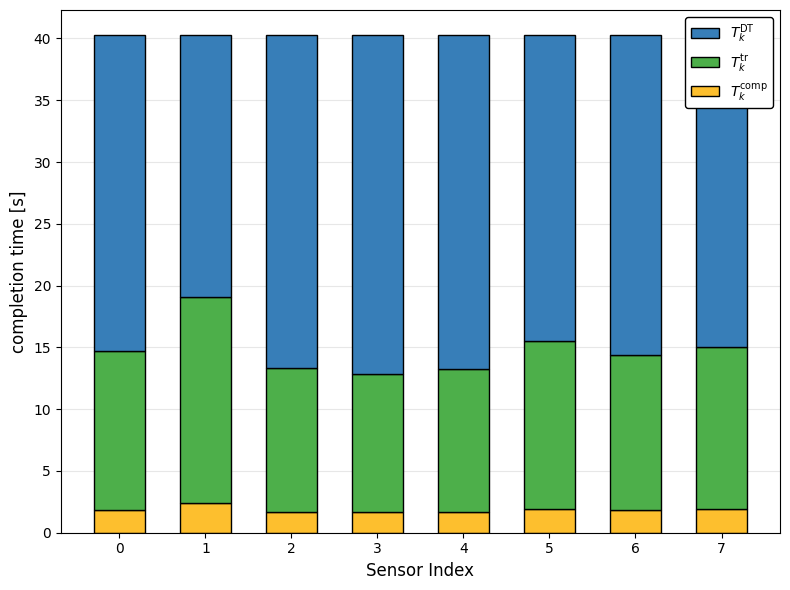

In [66]:
algo.optimize(model, max_iters=100)
    
algo.print_avg()
algo.plot()

CVX

c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:243: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:280: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:282: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 4.00e+03 |  -40.70 | 1.127e+04 | 5.594e+06 |   1.34 |     2.00e+05 |   3.16e-02 |         38.10 |         1.89 |      12.92 |      23.29 |
|            1 | 4.00e+03 |  -40.78 | 1.473e+04 | 7.554e+06 |   1.36 |     2.00e+05 |   3.16e-02 |         39.77 |         2.39 |      16.78 |      20.59 |
|            2 | 4.00e+03 |  -40.62 | 1.138e+04 | 5.641e+06 |   1.34 |     2.00e+05 |   3.16e-02 |         38.10 |         1.73 |      11.72 |      24.66 |
|            3 | 4.00e+03 |  -40.64 | 1.050e+04 | 5.200e+06 |   1.33 |     2.00e+05 |   3.16e-02 |         38.00 |         1.68 |      11.36 |      24.97 |
|            4 | 4.00e+03 |  -40.61 | 1.386e+04 | 6.936e+06 |   1.34 |     2.00e+05 |   3.16e-02 |         37.98 |         1.72 |      11.64 |      24.62 |
|            5 | 4.00e+03 |  -40.66 | 1.009e+04 | 5.090e+06 |   1.34 |     2.00e+05 |   3.16e-02 |         38.35 |         1.97 |      13.67 |      22.71 |
|            6 | 4.00e+03 |  -40.84 | 1.356e+04 | 6.771e+06 |   1.35 |     2.00e+05 |   3.16e-02 |         37.98 |         1.88 |      12.65 |      23.44 |
|            7 | 4.00e+03 |  -40.96 | 1.443e+04 | 7.214e+06 |   1.36 |     2.00e+05 |   3.16e-02 |         38.02 |         1.98 |      13.22 |      22.82 |

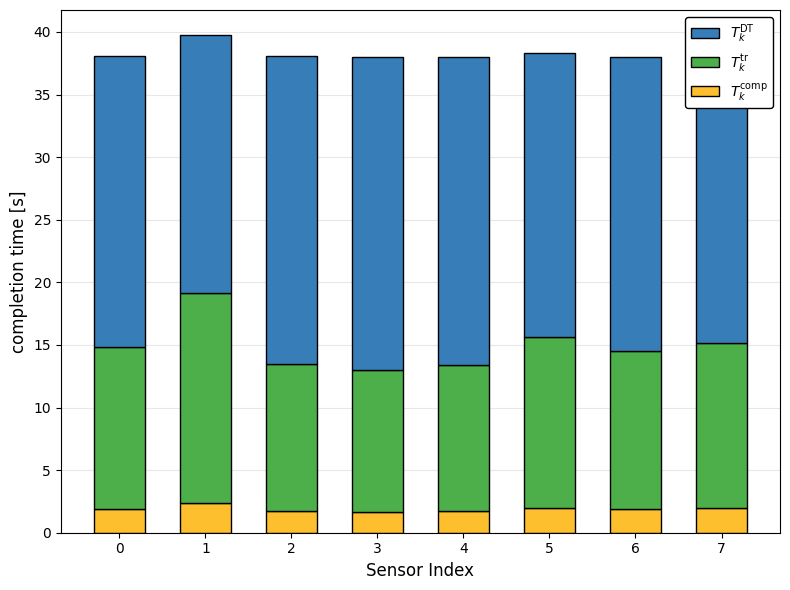

In [63]:
algo.optimize(model='cvx', max_iters=100)
    
algo.print_avg()
algo.plot()